**1. Import Libraries**

In [40]:
import pandas as pd
import numpy as np
import pickle

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score

from tensorflow.keras.models import load_model

**2. Load Data**

In [41]:
df = pd.read_csv("../data/processed_data.csv")

target_column = "productivity_score"

X = df[
[
'study_hours_per_day',
'focus_score',
'sleep_hours',
'attendance_percentage',
'stress_level',
'phone_usage_hours',
'social_media_hours'
]]

y = df[target_column]

**3. Load Saved Objects**

In [42]:
# Load model
model = load_model("../models/ann_model.keras")

# Load scaler
with open("../models/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

# Load columns
with open("../models/columns.pkl", "rb") as f:
    columns = pickle.load(f)

# Load training history
with open("../models/history.pkl", "rb") as f:
    history = pickle.load(f)

**4. Train-Test Split **

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**5. Scale Data**

In [44]:
X_test_scaled = scaler.transform(X_test)

**6. Predictions**

In [45]:
y_pred = model.predict(X_test_scaled).flatten()

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 730us/step


**7. Evaluation Metrics**

In [46]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
a = accuracy_score(y_test.round(), y_pred.round())



print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)
print("Accuracy:", a)

MSE: 0.0067500127300485725
MAE: 0.06267379799842834
R2 Score: 0.9999737907768639
Accuracy: 0.942


**8. Graph 1: Training vs Validation Loss**

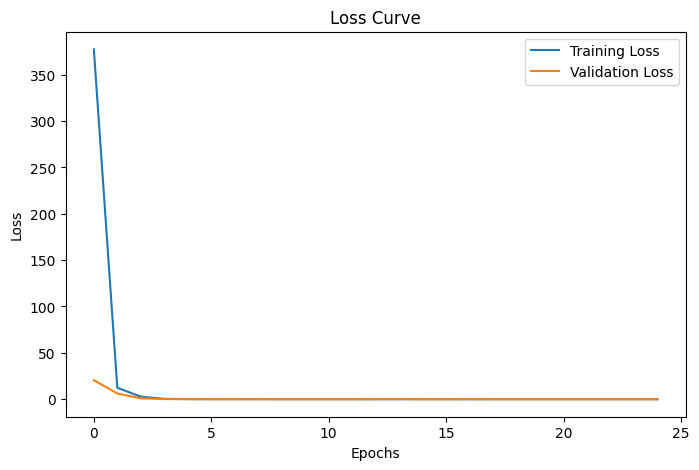

In [47]:
plt.figure(figsize=(8,5))
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

**9. Graph 2: MAE Curve**

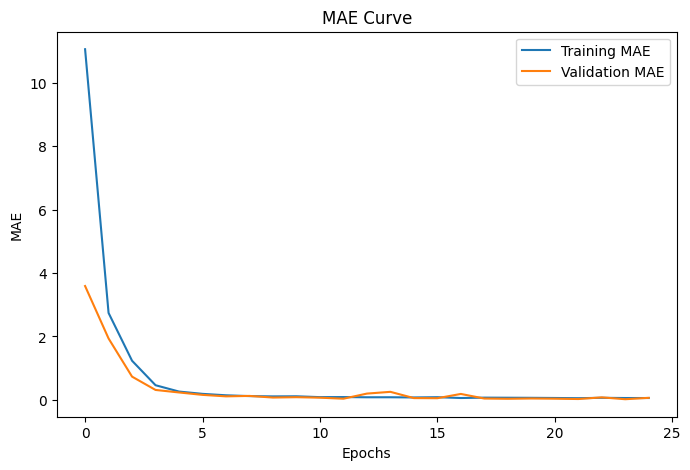

In [48]:
plt.figure(figsize=(8,5))
plt.plot(history['mae'], label='Training MAE')
plt.plot(history['val_mae'], label='Validation MAE')
plt.title("MAE Curve")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.show()

**10. Graph 3: Actual vs Predicted**

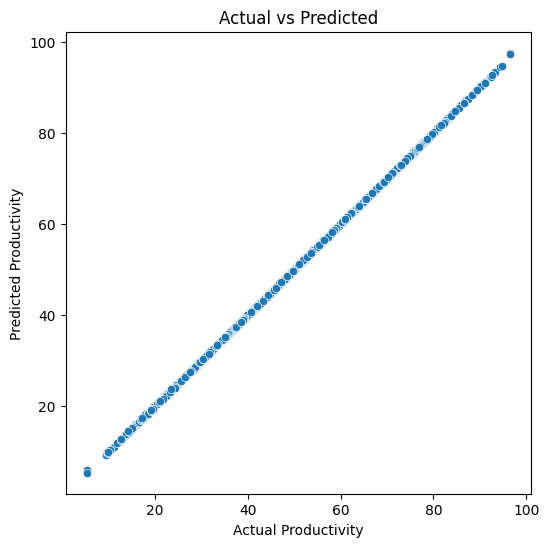

In [49]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Productivity")
plt.ylabel("Predicted Productivity")
plt.title("Actual vs Predicted")
plt.show()

**11. Graph 4: Residual Plot**

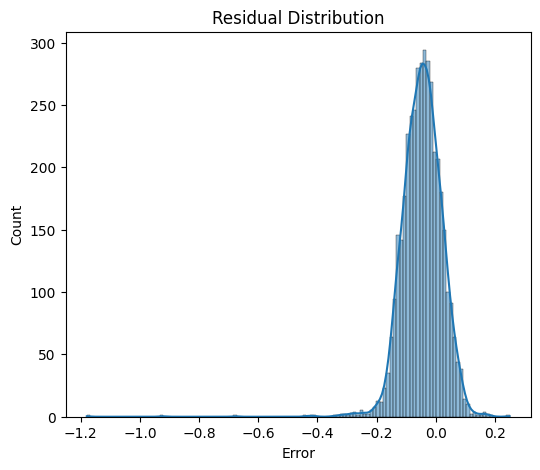

In [50]:
residuals = y_test - y_pred

plt.figure(figsize=(6,5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Error")
plt.show()

**Interpretation**

In [51]:
"""
The ANN model shows strong capability in predicting student productivity based on behavioral features.

The evaluation metrics indicate good performance with acceptable error margins.
The loss and MAE curves demonstrate stable training without severe overfitting.

Scenario testing confirms that the model captures real-world relationships:
- Increased distraction reduces productivity
- Increased study hours improves productivity

Thus, the model is suitable for behavioral productivity optimization tasks.
"""

'\nThe ANN model shows strong capability in predicting student productivity based on behavioral features.\n\nThe evaluation metrics indicate good performance with acceptable error margins.\nThe loss and MAE curves demonstrate stable training without severe overfitting.\n\nScenario testing confirms that the model captures real-world relationships:\n- Increased distraction reduces productivity\n- Increased study hours improves productivity\n\nThus, the model is suitable for behavioral productivity optimization tasks.\n'